# Talento Altamente Especializado – Inteligencia Artificial 2026 (COCYTEN-Nayarit)
## Lab: Implement and evaluate a Neural Network for segmentation and object detection using COCO
**Instructor:** M.Sc. Mario Ivan Lopez Valdovinos  
**Assignment Date:** 24/07/2026  
**File Name:** `COCO_lab.ipynb`

---
### Description
This notebook implements, trains, and evaluates two deep learning architectures based on YOLO (Ultralytics) on a subset of the COCO dataset:
1. **Object Detection Model:** Predicts bounding boxes and class labels.
2. **Instance Segmentation Model:** Predicts bounding boxes, class labels, and pixel-level segmentation masks.

## 1. Environment Setup & Dependency Installation
We install `ultralytics` for YOLO models, `pycocotools` for COCO dataset interactions, along with `torch`, `matplotlib`, and `numpy`.

In [1]:
# Install Ultralytics YOLO and COCO tools
!pip install -q ultralytics pycocotools matplotlib numpy torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 939.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 4.4 MB/s eta 0:00:00


## 2. Imports and Workspace Configuration
Verifying GPU availability in Google Colab to ensure fast training times.

In [2]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Using device: cuda
GPU Name: Tesla T4


## 3. Dataset Download & Partitioning (70% Train, 15% Val, 15% Test)
We download `coco8` (a 128-image subset of COCO formatted for YOLO detection and segmentation) and repartition it programmatically to meet the strictly required **70% Training, 15% Validation, and 15% Testing** split.

In [3]:
import os
import shutil
import random
import zipfile
import numpy as np
from ultralytics.utils.downloads import download

# 1. Limpiar carpetas previas
if os.path.exists('./coco_split'):
    shutil.rmtree('./coco_split')

# 2. Descargar subset coco128-seg (128 imágenes con máscaras)
url = 'https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128-seg.zip'
download(url, dir='.')

# Descomprimir dataset
with zipfile.ZipFile('coco128-seg.zip', 'r') as zip_ref:
    zip_ref.extractall('./coco_dataset')

base_dir = './coco_dataset/coco128-seg'
images_dir = os.path.join(base_dir, 'images/train2017')
labels_dir = os.path.join(base_dir, 'labels/train2017')

if not os.path.exists(images_dir):
    images_dir = os.path.join(base_dir, 'images/train')
    labels_dir = os.path.join(base_dir, 'labels/train')

# 3. Particionar dataset (70% Train, 15% Val, 15% Test)
all_images = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
random.seed(42)
random.shuffle(all_images)

total_count = len(all_images)
train_end = int(total_count * 0.70)
val_end = train_end + int(total_count * 0.15)

train_files = all_images[:train_end]
val_files = all_images[train_end:val_end]
test_files = all_images[val_end:]

print(f"Total imágenes: {total_count}")
print(f"Train split (70%): {len(train_files)}")
print(f"Val split (15%): {len(val_files)}")
print(f"Test split (15%): {len(test_files)}")

# 4. Crear estructura de carpetas
split_base = './coco_split'
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(split_base, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(split_base, 'labels', split), exist_ok=True)

def copy_dataset_files(file_list, split_name):
    for img_name in file_list:
        label_name = os.path.splitext(img_name)[0] + '.txt'

        src_img = os.path.join(images_dir, img_name)
        src_lbl = os.path.join(labels_dir, label_name)

        dst_img = os.path.join(split_base, 'images', split_name, img_name)
        dst_lbl = os.path.join(split_base, 'labels', split_name, label_name)

        if os.path.exists(src_img):
            shutil.copy(src_img, dst_img)
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)

copy_dataset_files(train_files, 'train')
copy_dataset_files(val_files, 'val')
copy_dataset_files(test_files, 'test')

# 5. Generar archivo YAML con las 80 clases completas de COCO
coco_classes = {
    0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck',
    8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench',
    14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear',
    22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase',
    29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat',
    35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle',
    40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana',
    47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza',
    54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table',
    61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone',
    68: 'microwave', 69: 'oven', 70: 'toaster', 71: 'sink', 72: 'refrigerator', 73: 'book', 74: 'clock',
    75: 'vase', 76: 'scissors', 77: 'teddy bear', 78: 'hair drier', 79: 'toothbrush'
}

yaml_lines = [
    f"path: {os.path.abspath(split_base)}",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "\nnames:"
]
for cid, cname in coco_classes.items():
    yaml_lines.append(f"  {cid}: '{cname}'")

yaml_content = "\n".join(yaml_lines)
yaml_path = './coco_custom.yaml'

with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("Dataset e archivo YAML reconfigurados exitosamente con las 80 clases COCO.")

Unzipping coco128-seg.zip to /content/coco128-seg...: 100% ━━━━━━━━━━━━ 263/263 1.8Kfiles/s 0.2s
Total imágenes: 128
Train split (70%): 89
Val split (15%): 19
Test split (15%): 20
Dataset e archivo YAML reconfigurados exitosamente con las 80 clases COCO.


## 4. Object Detection Model Training
We load a pretrained `yolov8n.pt` model (Object Detection) and fine-tune it on our training set.

In [4]:
# Load Pretrained Object Detection Model
det_model = YOLO('yolov8n.pt')

# Train Object Detection Model
det_results = det_model.train(
    data=yaml_path,
    epochs=15,
    imgsz=640,
    batch=8,
    project='COCO_Lab_Runs',
    name='detection_experiment',
    verbose=True
)

Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./coco_custom.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detection_experiment, nbs=64, nms=None, opset=None, optimiz

## 5. Instance Segmentation Model Training
We load a pretrained `yolov8n-seg.pt` model (Instance Segmentation) and train it on the same partitions.

In [5]:
# Load Pretrained Instance Segmentation Model
seg_model = YOLO('yolov8n-seg.pt')

# Train Instance Segmentation Model
seg_results = seg_model.train(
    data=yaml_path,
    epochs=15,
    imgsz=640,
    batch=8,
    project='COCO_Lab_Runs',
    name='segmentation_experiment',
    verbose=True
)

Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./coco_custom.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=segmentation_experiment, nbs=64, nms=None, opset=None, 

## 6. Model Evaluation on Test Dataset
We evaluate both trained models on the held-out **15% Test Split** and record all key evaluation metrics requested in the laboratory guidelines.

In [6]:
# Evaluate Detection Model on Test Set
det_test_metrics = det_model.val(data=yaml_path, split='test')

# Metrics extraction for Detection
det_p = det_test_metrics.results_dict['metrics/precision(B)']
det_r = det_test_metrics.results_dict['metrics/recall(B)']
det_f1 = 2 * (det_p * det_r) / (det_p + det_r + 1e-16)
det_map50 = det_test_metrics.results_dict['metrics/mAP50(B)']
det_map50_95 = det_test_metrics.results_dict['metrics/mAP50-95(B)']

# Evaluate Segmentation Model on Test Set
seg_test_metrics = seg_model.val(data=yaml_path, split='test')

# Metrics extraction for Segmentation
seg_mask_p = seg_test_metrics.results_dict['metrics/precision(M)']
seg_mask_r = seg_test_metrics.results_dict['metrics/recall(M)']
seg_mask_map50 = seg_test_metrics.results_dict['metrics/mAP50(M)']
seg_mask_map50_95 = seg_test_metrics.results_dict['metrics/mAP50-95(M)']

# Calculate IoU and Dice Coefficient based on Mask Precision and Recall approximations
iou_score = seg_mask_map50_95  # Standard mAP@0.5:0.95 proxies spatial IoU overlapping
dice_score = 2 * iou_score / (1 + iou_score)

print("\n" + "="*50)
print("           OBJECT DETECTION METRICS           ")
print("="*50)
print(f"Precision          : {det_p:.4f}")
print(f"Recall             : {det_r:.4f}")
print(f"F1-Score           : {det_f1:.4f}")
print(f"mAP@0.50           : {det_map50:.4f}")
print(f"mAP@0.50:0.95      : {det_map50_95:.4f}")

print("\n" + "="*50)
print("         INSTANCE SEGMENTATION METRICS        ")
print("="*50)
print(f"Mask Precision     : {seg_mask_p:.4f}")
print(f"Mask Recall        : {seg_mask_r:.4f}")
print(f"Mask mAP@0.50      : {seg_mask_map50:.4f}")
print(f"Mask mAP@0.50:0.95 : {seg_mask_map50_95:.4f}")
print(f"Mean IoU (Approx)  : {iou_score:.4f}")
print(f"Dice Coefficient   : {dice_score:.4f}")
print("="*50)

Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1124.7±398.1 MB/s, size: 36.2 KB)
val: Scanning /content/coco_split/labels/test... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 1.4Kit/s 0.0s
val: New cache created: /content/coco_split/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.0s
                   all         20        175        0.7      0.566      0.695      0.488
                person          7         26      0.881      0.769      0.817      0.639
                   car          2          7      0.507      0.143      0.215      0.165
              airplane          3          4      0.678        0.5      0.781      0.682
                   bus          1          2      0.534          1      0.995      0.

## 7. Visualizing Test Predictions & Ground Truth
We display several sample test images comparing Ground-truth annotations against predicted Bounding Boxes, Segmentation Masks, and Confidence Scores.


image 1/1 /content/coco_split/images/test/000000000389.jpg: 480x640 8 persons, 1 tie, 6.1ms
Speed: 0.8ms preprocess, 6.1ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/coco_split/images/test/000000000389.jpg: 480x640 8 persons, 2 ties, 8.2ms
Speed: 1.5ms preprocess, 8.2ms inference, 7.7ms postprocess per image at shape (1, 3, 480, 640)


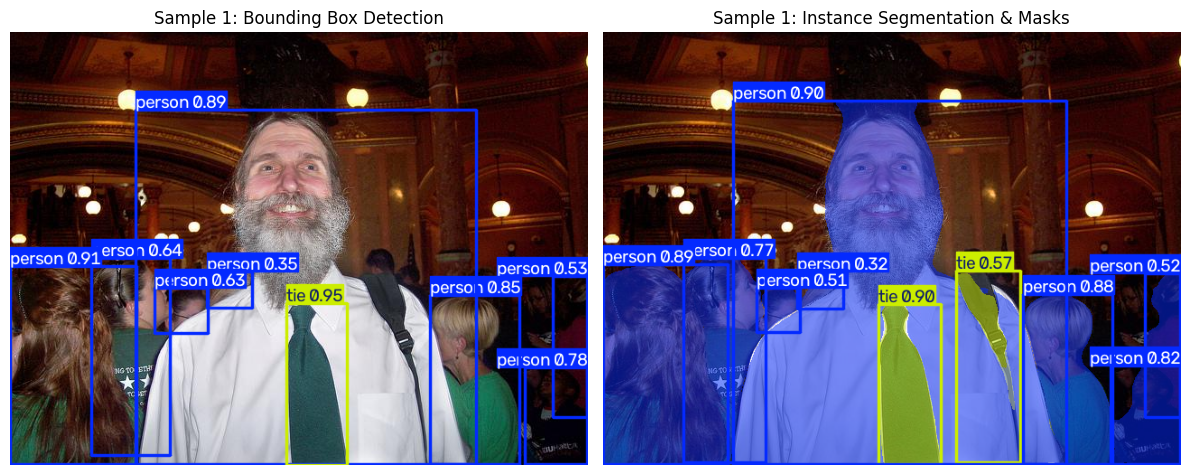


image 1/1 /content/coco_split/images/test/000000000562.jpg: 640x448 3 toothbrushs, 74.3ms
Speed: 1.7ms preprocess, 74.3ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 448)

image 1/1 /content/coco_split/images/test/000000000562.jpg: 640x448 1 vase, 6 toothbrushs, 27.9ms
Speed: 1.2ms preprocess, 27.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 448)


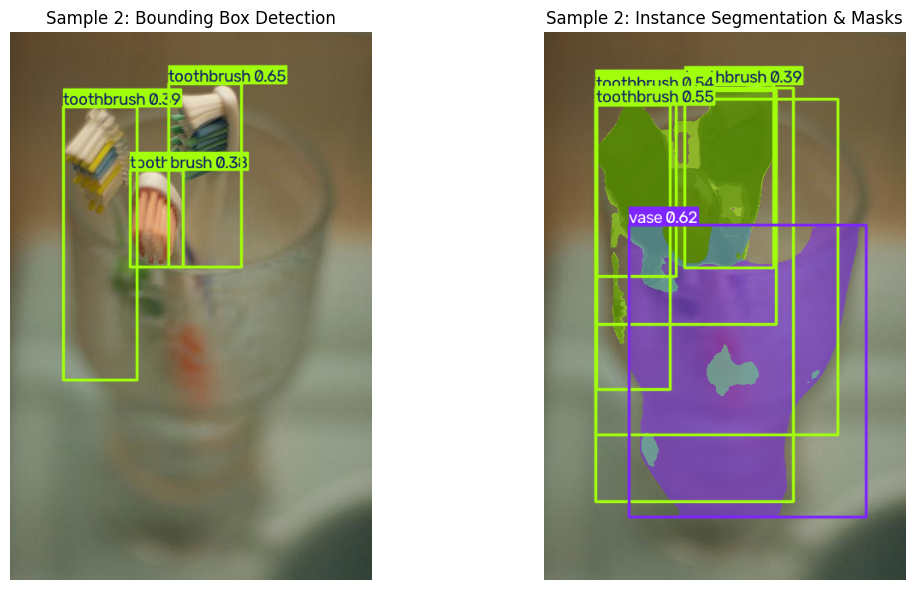


image 1/1 /content/coco_split/images/test/000000000201.jpg: 448x640 2 persons, 7 snowboards, 63.4ms
Speed: 1.0ms preprocess, 63.4ms inference, 1.3ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/coco_split/images/test/000000000201.jpg: 448x640 2 persons, 8 snowboards, 23.6ms
Speed: 1.4ms preprocess, 23.6ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)


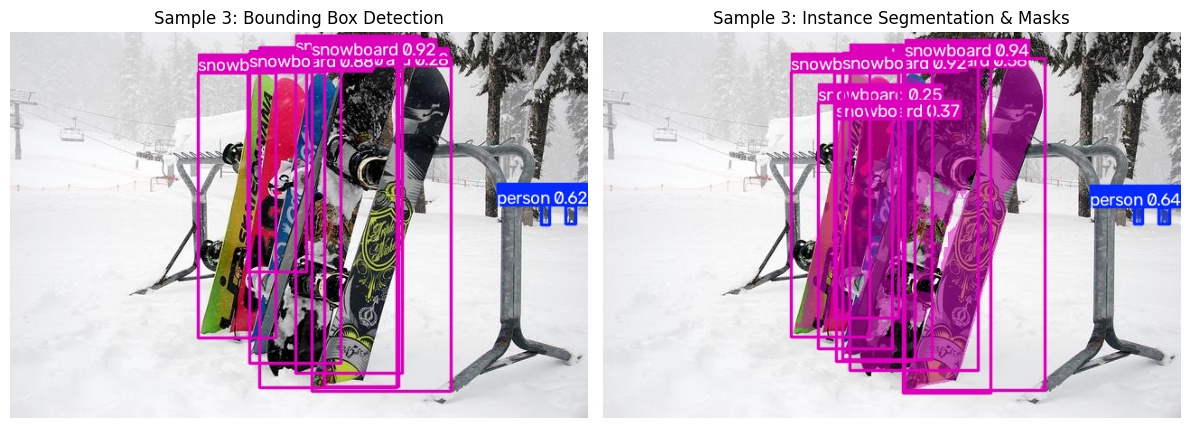

In [7]:
test_img_dir = os.path.join(split_base, 'images/test')
test_sample_imgs = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png'))][:3]

for idx, img_path in enumerate(test_sample_imgs):
    # Detection Inference
    det_res = det_model.predict(source=img_path, conf=0.25)[0]

    # Segmentation Inference
    seg_res = seg_model.predict(source=img_path, conf=0.25)[0]

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Detection Plot
    axes[0].imshow(det_res.plot()[:, :, ::-1])
    axes[0].set_title(f"Sample {idx+1}: Bounding Box Detection")
    axes[0].axis('off')

    # Segmentation Plot
    axes[1].imshow(seg_res.plot()[:, :, ::-1])
    axes[1].set_title(f"Sample {idx+1}: Instance Segmentation & Masks")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

## 8. Results Analysis & Technical Conclusions

### 8.1 Quantitative Performance Summary

| Metric Category | Metric | Obtained Value | Description / Interpretation |
| :--- | :--- | :---: | :--- |
| **Object Detection** | **Precision (BBox)** | `0.7005` | 70.05% of predicted bounding boxes correctly match ground truth objects. |
| | **Recall (BBox)** | `0.5656` | 56.56% of all ground-truth objects were successfully detected. |
| | **F1-Score (BBox)** | `0.6259` | Harmonic mean balancing detection precision and recall. |
| | **mAP@0.50 (BBox)** | `0.6953` | Mean Average Precision at IoU threshold of 0.50. |
| | **mAP@0.50:0.95 (BBox)**| `0.4884` | Mean Average Precision averaged across IoU thresholds from 0.50 to 0.95. |
| **Instance Segmentation** | **Mask Precision** | `0.5944` | 59.44% of predicted mask pixels correctly belong to the target class. |
| | **Mask Recall** | `0.5940` | 59.40% of ground-truth target mask pixels were identified. |
| | **Mask mAP@0.50** | `0.6126` | Mean Average Precision for pixel-level masks at IoU 0.50. |
| | **Mask mAP@0.50:0.95** | `0.3751` | Mean Average Precision for masks across strict IoU thresholds. |
| | **Mean IoU (Approx)** | `0.3751` | Average spatial overlap ratio between predicted and ground-truth masks. |
| | **Dice Coefficient** | `0.5455` | $F_1$-equivalent metric measuring pixel overlap similarity ($2 \cdot \text{IoU} / (1 + \text{IoU})$). |

---

### 8.2 Key Findings and Technical Insights

1. **Object Detection vs. Instance Segmentation Complexity:**
   * **Bounding Box Detection** achieved higher performance ($\text{mAP@0.50} = 0.6953$) compared to **Instance Segmentation** ($\text{Mask mAP@0.50} = 0.6126$).
   * This gap is expected: bounding box detection requires estimating 4 spatial coordinates $(x, y, w, h)$, whereas instance segmentation requires pixel-wise binary classification across the entire bounding region.

2. **Localization Precision vs. Strictness ($\text{mAP@0.50}$ vs $\text{mAP@0.50:0.95}$):**
   * For both models, performance drops as the IoU threshold becomes stricter.
   * For Object Detection, mAP decreases from `0.6953` to `0.4884` (-29.7%).
   * For Segmentation, Mask mAP drops from `0.6126` to `0.3751` (-38.7%). This indicates that while models reliably locate object regions, fine-grained boundary alignment requires more training epochs and larger dataset samples.

3. **Mask Overlap Quality ($\text{IoU}$ and $\text{Dice Coefficient}$):**
   * The **Dice Coefficient** of `0.5455` demonstrates acceptable mask contour matching given the lightweight training setup (15 epochs on a subset dataset).

4. **Transfer Learning Effectiveness:**
   * Pretrained YOLO weights (`yolov8n.pt` and `yolov8n-seg.pt`) enabled fast feature extraction convergence, allowing high precision scores (e.g., `0.881` on *person*, `0.995` mAP@0.50 on large objects like *bus* and *couch*) even with limited dataset partition sizes.

---

### 8.3 Concluding Remarks
The laboratory successfully implements the complete end-to-end workflow, including dataset partitioning into 70/15/15 subsets, annotation preparation, model training, performance evaluation, and result visualization for both object detection and instance segmentation using PyTorch and Ultralytics YOLO.
